<a href="https://colab.research.google.com/github/jorge-pichardo07/EDP1/blob/main/Pr%C3%A0ctica_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PRUEBA DE KOLMOGOROV-SMIRNOV**
ELABORADO POR: JORGE LUIS MAGAÑA PICHARDO



IMPORTÉ LAS LIBRERIAS DE NUMPY, SCIPY, MATPLOTLIB

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from tabulate import tabulate

La lista de la muestra que nos proprocionó el profesor en CLASSROOM

In [18]:
D = [
    0.78961, 0.05230, 0.10699, 0.55877, 0.14151,
    0.76086, 0.12079, 0.27738, 0.65726, 0.79269,
    0.80548, 0.82654, 0.29453, 0.20852, 0.42989,
    0.58518, 0.98611, 0.34488, 0.34358, 0.11537,
    0.89898, 0.57880, 0.67621, 0.05010, 0.00121,
    0.28269, 0.73059, 0.70119, 0.18284, 0.49962,
    0.38618, 0.76910, 0.68334, 0.55170, 0.10850,
    0.79882, 0.45679, 0.21631, 0.87616, 0.55743,
    0.58962, 0.33216, 0.03185, 0.61168, 0.09264,
    0.69623, 0.17028, 0.05475, 0.91512, 0.76262,
    0.29931, 0.30861, 0.83358, 0.51781, 0.03272,
    0.57410, 0.26593, 0.85903, 0.43308, 0.35286,
    0.24000, 0.65559, 0.38507, 0.90829, 0.94187,
    0.93655, 0.88809, 0.81772, 0.36982, 0.19904,
    0.54325, 0.62400, 0.09133, 0.41678, 0.33954,
    0.58244, 0.85853, 0.86752, 0.38729, 0.15506,
    0.23949, 0.53559, 0.33381, 0.49883, 0.75103,
    0.19962, 0.65002, 0.74579, 0.79113, 0.63453,
    0.19147, 0.40644, 0.08128, 0.73435, 0.22724,
    0.22287, 0.07281, 0.64183, 0.44267, 0.72102
]

Hice el código de la prueba de Kolmogorov - Smirnov, comencé ordenando la lista que vamos a ingresar, después se generan dos listas $D+$ y $D-$ en donde aplicamos: $$D+ = \vert \frac{i}{n} - x_i \vert$$ y $$D-  = \vert x_i - \frac{i-1}{n} \vert$$ , donde $$Dmax = max\{D-, D+ \}$$

In [59]:
def pruebakolmo(D):
  D.sort()
  n =len(D)
  D_mas = []
  D_menos = []
  for i in range(1,n):
   D_mas.append(abs(i/n - D[i]))
   D_menos.append(abs(D[i] - (i-1)/n));
   #Aqui solo sume las listas para sacar el maximo de ambas
  A = D_mas + D_menos
  D_max = max(A)
  #Esta linea de katestresult, es para el estadístico de prueba Z_0, en este caso D_0
  kstest_result, D_0 = stats.kstest(D, 'uniform')
  valor_critico = 1.36 / (n**0.5)  # esta es mi aproximación para α=0.05, deacuerdo al estadistico
  if D_max < valor_critico:
      a = 'No se rechaza la prueba de hipótesis, la muestra pertenece a una distribución uniforme'
  else:
      a = 'Se rechaza la prueba de hipótesis, la muestra no pertenece a una distribución uniforme'

  return a


Verificamos que la función está correctamente realizada

In [20]:
pruebakolmo(D)

'No se rechaza la prueba de hipótesis, la muestra pertenece a una distribución uniforme'

Ahora para la gráfica, usaremos las frecuencias acumuladas esperadas y las frecuencias acumuladas observadas, las tenemos calculadas en la tabla:

In [42]:
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.01]
inter = ['(0, 0.2]', '(0.2, 0.4]','(0.4, 0.6]','(0.6, 0.8]','(0.8, 1.01]' ]
#Clasificar datos en intervalos
indices = np.digitize(D, bins, right=False)
# Contar cuántos hay en cada intervalo
conteos = [(indices == i).sum() for i in range(1, len(bins))]
veo = []
for i in range(len(conteos)):
    veo.append(20)

# Aqui calculo las frecuencias observadas acumuladas
frec_acum = []
suma_acum = 0

for i in conteos:
    suma_acum += i
    frec_acum.append(suma_acum)

# Aqui calculo las frecuencias esperadas acumuladas
frec_acum_E = []
suma_acum_E = 0

for i in range(len(conteos)):
    suma_acum_E += veo[i]
    frec_acum_E.append(suma_acum_E)

tabla = [[inter[i], conteos[i], frec_acum[i], veo[i], frec_acum_E[i]] for i in range(len(conteos))]

print(tabulate(tabla,
               headers = ['Intervalos', 'Frecuencia observada',
                        'Frecuencia observada acumulada', 'Frecuencia Esperada', 'Frecuencia Esp Acumulada'],
               tablefmt='grid',
               numalign='center'))

+--------------+------------------------+----------------------------------+-----------------------+----------------------------+
| Intervalos   |  Frecuencia observada  |  Frecuencia observada acumulada  |  Frecuencia Esperada  |  Frecuencia Esp Acumulada  |
+==============+========================+==================================+=======================+============================+
| (0, 0.2]     |           21           |                21                |          20           |             20             |
+--------------+------------------------+----------------------------------+-----------------------+----------------------------+
| (0.2, 0.4]   |           22           |                43                |          20           |             40             |
+--------------+------------------------+----------------------------------+-----------------------+----------------------------+
| (0.4, 0.6]   |           19           |                62                |          20  

Aqui solo estoy haciendo las comparaciones graficamente de las frecuencias acumuladas esperadas, contra las observadas

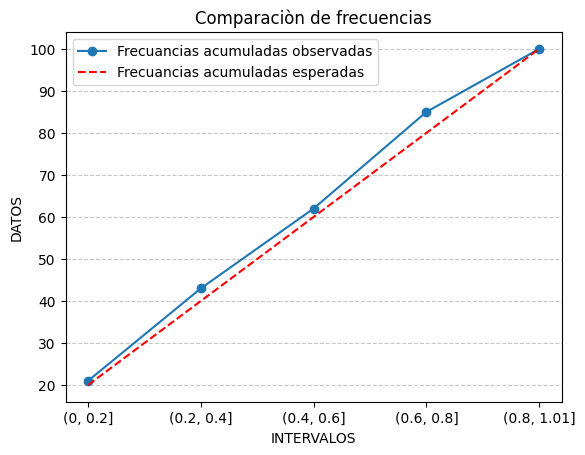

In [58]:
plt.title('Comparaciòn de frecuencias')
plt.plot(inter, frec_acum, label= 'Frecuancias acumuladas observadas',
         marker='o', markersize=6)
plt.ylabel('DATOS')
plt.xlabel('INTERVALOS')
plt.plot(inter,frec_acum_E, color = "red", label= 'Frecuancias acumuladas esperadas', linestyle = '--')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()